## 컬리 패션 카테고리 EDA

`kurly_crawler.py`로 수집한 컬리 패션 카테고리(165 패션의류 등) 상품·리뷰 데이터 EDA.
무신사 EDA(`analysis.ipynb`)와 같은 흐름이되, 컬리 데이터 특성에 맞춰 조정했다.

- **별점 없음** → 평점 분석 대신 리뷰수(누적 판매 프록시) 집중도 분석
- **리뷰 수 상한 표기(`999+`)** → 999로 치환하고 상한 도달 여부를 따로 보존
- **브랜드 필드 없음** → 상품명 `[브랜드]` 추출값이라 미표기 상품 존재

In [1]:
import json
import re
from collections import Counter
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 차트 팔레트 — 시리즈는 파랑 단일 색, 긍/부정 비교만 파랑↔빨강 (극성 대비)
BLUE, RED = '#2a78d6', '#e34948'
INK, SECONDARY, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
SURFACE = '#fcfcfb'

# 설치된 한글 폰트를 골라 하나만 지정 (리스트로 주면 없는 폰트마다 경고가 나옴)
_available = {f.name for f in font_manager.fontManager.ttflist}
FONT = next((f for f in ('Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR')
             if f in _available), 'DejaVu Sans')

plt.rcParams.update({
    'font.family': FONT,
    'axes.unicode_minus': False,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#c3c2b7',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'text.color': INK, 'axes.labelcolor': SECONDARY,
    'xtick.color': MUTED, 'ytick.color': MUTED,
})

#### 데이터 로드 · 전처리

`CATEGORY`만 바꾸면 166·169 등 다른 카테고리도 같은 노트북으로 분석할 수 있다.

In [2]:
CATEGORY = '169'  # 165 패션의류 · 166 · 169 — 수집해 둔 카테고리 코드로 변경

# 같은 카테고리를 여러 날 수집해도 최신 파일을 집도록 glob 사용
with open(sorted(glob(f'data/kurly_products_{CATEGORY}_*.json'))[-1], encoding='utf-8') as f:
    prod = pd.DataFrame(json.load(f)).drop(columns=['_goods_no'])

rev_files = sorted(glob(f'data/kurly_reviews_{CATEGORY}_*.json'))
if rev_files:
    with open(rev_files[-1], encoding='utf-8') as f:
        rev = pd.DataFrame(json.load(f))
else:
    rev = pd.DataFrame()
    print('리뷰 파일이 없습니다 — 5장(리뷰 텍스트)은 리뷰 수집 후 실행하세요.')

CATEGORY_NAME = prod['Category'].iloc[0]
prod.shape, rev.shape

((96, 11), (842, 6))

In [3]:
# 문자열 필드를 숫자로 변환 (품절 등으로 가격이 빈 상품은 제외)
prod['가격'] = pd.to_numeric(prod['Price'].str.replace(',', ''), errors='coerce')
prod['정가'] = pd.to_numeric(prod['Original Price'].str.replace(',', ''), errors='coerce')
prod = prod.dropna(subset=['가격']).astype({'가격': int, '정가': int})
prod['할인율'] = pd.to_numeric(prod['Discount Rate'].str.rstrip('%'), errors='coerce').fillna(0).astype(int)

# 리뷰 수는 '999+'처럼 상한 표기가 있어 숫자로 바꾸고 상한 여부를 보존
prod['리뷰수상한'] = prod['Review Count'].str.endswith('+')
prod['리뷰수'] = prod['Review Count'].str.replace(',', '').str.rstrip('+').astype(int)

prod['브랜드'] = prod['Brand'].replace('', '(미표기)')

if len(rev):
    rev['날짜'] = pd.to_datetime(rev['Review Date'], errors='coerce')
    rev['본문길이'] = rev['Review Body'].str.len()

prod[['Rank', '브랜드', 'Product Name', '가격', '할인율', '리뷰수']].head()

,Rank,브랜드,Product Name,가격,할인율,리뷰수
0,1,라페어,[라페어] 스킨무드 인견 솔리드 팬티 세트 5매입 5종 (택1),27930,43,999
1,2,마른파이브,[마른파이브] 브리즈 모달 캡내장 브라탑 12종 (택1),10997,46,999
2,3,티세르,[티세르] 마리나 시어서커 커플 반팔 잠옷 상하세트,12530,79,151
3,4,어나더디,[어나더디] (1+1) 냉감소재 쿨소프트 끈 브라탑,11815,40,101
4,5,마른파이브,[마른파이브] 하늘인견 브라캡 나시 9종 (택1),19950,35,365


#### 1. 가격대 분포

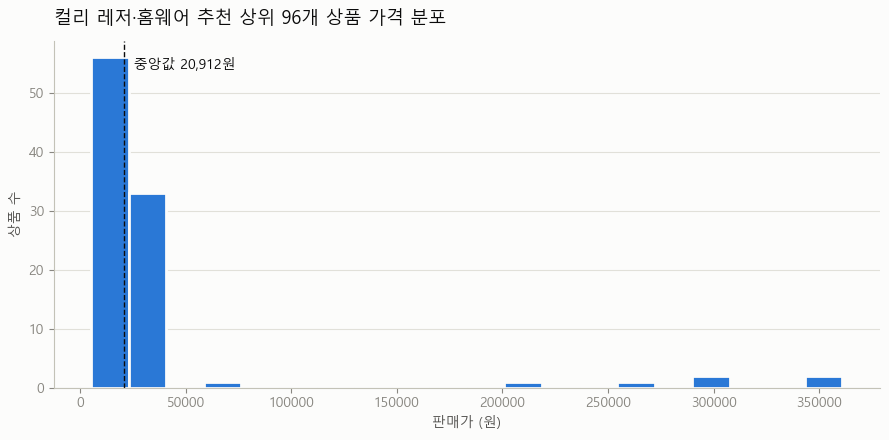

가격 범위 5,299~399,000원 / 중앙값 20,912원


In [4]:
cap = int(prod['가격'].quantile(0.99))  # 극단 고가 1%는 마지막 구간에 몰아넣어 가독성 확보
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prod['가격'].clip(upper=cap), bins=20, color=BLUE, edgecolor=SURFACE, linewidth=2)
med = prod['가격'].median()
ax.axvline(med, color=INK, linewidth=1, linestyle='--')
ax.text(med, ax.get_ylim()[1] * 0.95, f'  중앙값 {med:,.0f}원', va='top', fontsize=10)
ax.set_xlabel('판매가 (원)')
ax.set_ylabel('상품 수')
ax.set_title(f'컬리 {CATEGORY_NAME} 추천 상위 {len(prod)}개 상품 가격 분포', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f"가격 범위 {prod['가격'].min():,}~{prod['가격'].max():,}원 / 중앙값 {med:,.0f}원")

**주력 1~3만원, 중앙값 20,912원 — 무신사 026보다 낮은 단가**

- 가격 범위 5,299~399,000원. 같은 속옷·홈웨어 성격인 무신사 026(중앙값 34,405원)보다 39% 낮다
- 팬티 5매입·잠옷 상하세트 등 세트 단위 저단가 구성이 상위권을 채운다

#### 2. 할인 구조

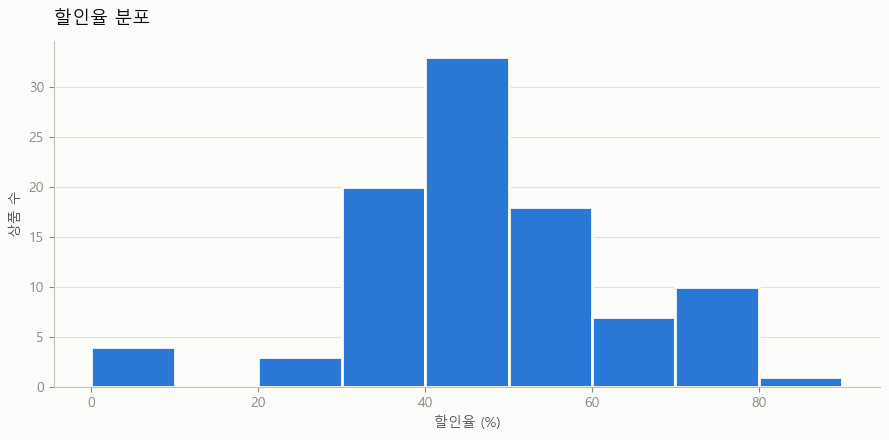

정가 판매(0%): 4개 / 96개
할인율 중앙값 45%, 최대 89%
25% 이상 할인 상품 비율: 94%


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prod['할인율'], bins=range(0, prod['할인율'].max() + 11, 10), color=BLUE,
        edgecolor=SURFACE, linewidth=2)
ax.set_xlabel('할인율 (%)')
ax.set_ylabel('상품 수')
ax.set_title('할인율 분포', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

n = len(prod)
print(f"정가 판매(0%): {(prod['할인율'] == 0).sum()}개 / {n}개")
print(f"할인율 중앙값 {prod['할인율'].median():.0f}%, 최대 {prod['할인율'].max()}%")
print(f"25% 이상 할인 상품 비율: {(prod['할인율'] >= 25).mean():.0%}")

**정가 판매 4개(4%) — '정가'는 사실상 앵커 가격**

- 96개 중 92개가 할인 중. 할인율 중앙값 45%(최대 89%), 25% 이상 할인이 94%
- '절반이 25%+'였던 무신사 026보다 훨씬 극단적인 상시할인 — 할인을 전제로 정가를 설계하는 구조로, 실판매가 기준 비교가 아니면 채널 비교가 왜곡된다

#### 3. 브랜드 구도

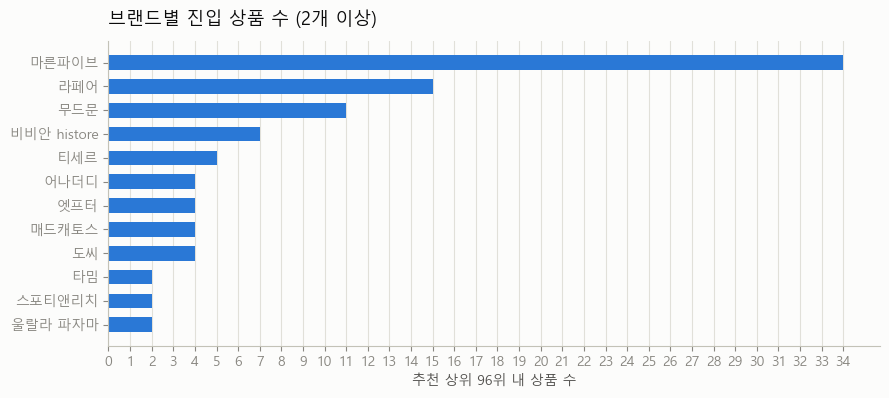

브랜드 미표기 상품: 0개 (0%)
1개 상품 브랜드: 2개


In [6]:
named = prod[prod['브랜드'] != '(미표기)']
brand_cnt = named['브랜드'].value_counts()
top = brand_cnt[brand_cnt >= 2].sort_values()

fig, ax = plt.subplots(figsize=(9, max(3.5, 0.34 * len(top))))
ax.barh(top.index, top.values, color=BLUE, height=0.62)
ax.set_xlabel(f'추천 상위 {len(prod)}위 내 상품 수')
ax.set_title('브랜드별 진입 상품 수 (2개 이상)', loc='left', fontsize=13, pad=12)
ax.set_xticks(range(0, int(top.max()) + 1))
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

print(f"브랜드 미표기 상품: {(prod['브랜드'] == '(미표기)').sum()}개 ({(prod['브랜드'] == '(미표기)').mean():.0%})")
print(f"1개 상품 브랜드: {(brand_cnt == 1).sum()}개")

**마른파이브 34개 — 열린 마켓이 아니라 소수 브랜드 반복 큐레이션**

- 마른파이브(34)·라페어(15) 두 브랜드가 상위 노출 96개의 절반을 차지. 1개 상품 브랜드는 2개(무신사 026은 11개)
- 무신사가 '다수 브랜드 경쟁 + PB 볼륨' 구조라면, 컬리는 입점 브랜드의 상품 라인을 통째로 반복 노출한다

#### 4. 리뷰수 집중도 — 판매가 얼마나 소수 상품에 쏠려 있나

컬리는 별점이 없어 리뷰수(누적 판매 프록시)의 분포로 상품 간 변별을 본다.
`999+`는 999로 치환된 값이라 실제 집중도는 이보다 **더 높다**(보수적 추정).

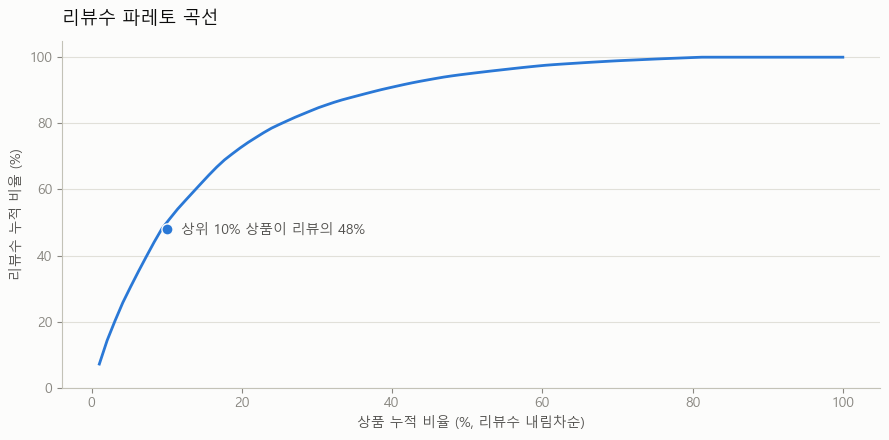

리뷰 0건 상품: 18개 / 96개
리뷰수 상한(999+) 도달 상품: 2개


In [7]:
s = prod['리뷰수'].sort_values(ascending=False).reset_index(drop=True)
share = s.cumsum() / s.sum() * 100
x = (s.index + 1) / len(s) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, share, color=BLUE, linewidth=2)
p10 = share.iloc[max(0, int(len(s) * 0.1) - 1)]
ax.scatter([10], [p10], s=64, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=1)
ax.annotate(f'상위 10% 상품이 리뷰의 {p10:.0f}%', (10, p10),
            textcoords='offset points', xytext=(10, -4), fontsize=10, color=SECONDARY)
ax.set_xlabel('상품 누적 비율 (%, 리뷰수 내림차순)')
ax.set_ylabel('리뷰수 누적 비율 (%)')
ax.set_ylim(0, 105)
ax.set_title('리뷰수 파레토 곡선', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f"리뷰 0건 상품: {(prod['리뷰수'] == 0).sum()}개 / {len(prod)}개")
print(f"리뷰수 상한(999+) 도달 상품: {prod['리뷰수상한'].sum()}개")

**상위 10% 상품이 리뷰의 48% — 잡화(75%)보다는 분산**

- 리뷰 0건 상품 18/96. 리뷰수 상한(999+) 도달 상품 2개 — 실제 집중도는 이보다 높다(보수적 추정)
- 저단가 반복구매 카테고리라 잡화 대비 수요가 넓게 퍼져, 신규 상품 진입 여지가 상대적으로 크다

#### 5. 리뷰 텍스트 — 무엇에 만족하고 무엇을 걱정하나

별점이 없으므로 평점 그룹 비교 대신 **전체 리뷰의 빈출 키워드와 속성 언급률**을 본다.
(수집 리뷰는 추천순 상위라 긍정 편향이 있음을 감안하고 읽는다.)

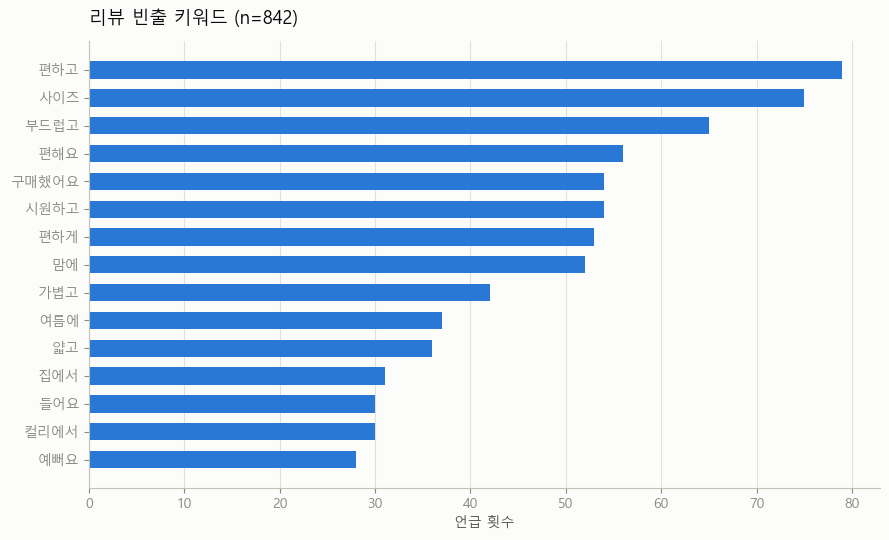

In [8]:
# 리뷰 미수집 상태면 이 장은 건너뛴다
if rev.empty:
    print('리뷰 파일이 없습니다 — 리뷰 수집 후 실행하세요.')
else:
    # 간단 토큰화(2글자 이상 한글) + 범용 표현 불용어 제거
    STOP = set('있어요 있습니다 같아요 그리고 너무 정말 진짜 그냥 조금 아주 많이 잘 더 좀 것 수 때 거 '
               '저는 제가 근데 하고 입니다 있는 없이 같은 살짝 완전 계속 다시 하나 해서 위에 이번 다른 '
               '이거 봐요 봐서 그래서 하는 한 번 안 못 딱 좋아요 좋습니다 좋아서 좋고 좋음 굿 최고 '
               '만족합니다 만족해요 않고 엄청 생각보다 좋네요 마음에 입기 입고 입을 입어도 구매 주문 '
               '컬리 샀는데 사서 사길 했어요 했는데 합니다 해요'.split())

    def tokens(text):
        return [t for t in re.findall(r'[가-힣]{2,}', str(text)) if t not in STOP]

    top15 = pd.Series(Counter(t for s in rev['Review Body'] for t in tokens(s))).nlargest(15)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(top15.index[::-1], top15.values[::-1], color=BLUE, height=0.62)
    ax.set_xlabel('언급 횟수')
    ax.set_title(f'리뷰 빈출 키워드 (n={len(rev)})', loc='left', fontsize=13, pad=12)
    ax.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

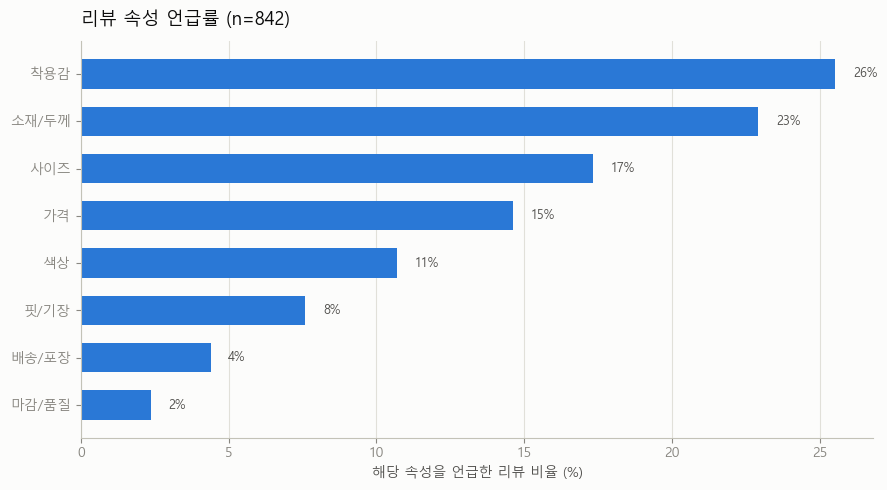

In [9]:
# 리뷰 미수집 상태면 이 장은 건너뛴다
if rev.empty:
    print('리뷰 파일이 없습니다 — 리뷰 수집 후 실행하세요.')
else:
    # 속성 사전 기반 언급률 — 패션 카테고리 공통 속성
    ASPECTS = {
        '사이즈': '사이즈|크기',
        '핏/기장': '핏|기장|어깨|허리|통이',
        '소재/두께': '소재|원단|재질|두께|얇|두껍',
        '색상': '색상|색감|컬러|색이',
        '착용감': '편하|편안|불편',
        '마감/품질': '마감|봉제|박음질|실밥|보풀|품질',
        '배송/포장': '배송|포장',
        '가격': '가격|가성비|세일|할인',
    }
    rates = pd.Series(
        {k: rev['Review Body'].str.contains(p).mean() * 100 for k, p in ASPECTS.items()}
    ).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(rates.index, rates.values, color=BLUE, height=0.62)
    for i, v in enumerate(rates.values):
        ax.text(v + 0.6, i, f'{v:.0f}%', va='center', fontsize=9, color=SECONDARY)
    ax.set_xlabel('해당 속성을 언급한 리뷰 비율 (%)')
    ax.set_title(f'리뷰 속성 언급률 (n={len(rev)})', loc='left', fontsize=13, pad=12)
    ax.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

    rates.sort_values(ascending=False).round(1)

**착용감·소재·사이즈가 홈웨어 구매의 핵심 — 기능 중심 언어**

- 속성 언급률: 착용감 26% · 소재/두께 23% · 사이즈 17% 순. 저단가 홈웨어라 '편안함·소재감·사이즈'가 만족의 축
- 빈출 키워드도 '편하고·부드럽고·시원하고·편해요' 등 기능·계절 언어가 지배적 — 165(자연스럽게·스트라이프)의 스타일 언어와 대비된다
- 별점이 없어 저평점 비교가 불가하므로, 후속으로 '불편·아쉽·별로' 등 부정 표현과 동시 등장하는 속성을 집계할 예정

#### 종합 인사이트

1. **가격/할인**: 중앙값 20,912원·정가 판매 4%·할인 중앙값 45% — 할인 전제 가격 설계. 무신사 026 대비 저단가·고할인
2. **브랜드**: 마른파이브·라페어 두 브랜드가 절반 — 소수 브랜드 반복 큐레이션 구조
3. **수요 집중도**: 상위 10%가 리뷰의 48%(999+ 절단 감안 시 그 이상) — 잡화보다 분산
4. **다음**: 리뷰 본문 수집 후 부정 표현 동반 속성 분석(5장), 무신사 026과 홈웨어 직접 비교